## **Stock Market News Sentiment Analysis**

### Business Context

The prices of the stocks of companies listed under a global exchange are influenced by a variety of factors, with the company's financial performance, innovations and collaborations, and market sentiment being factors that play a significant role. News and media reports can rapidly affect investor perceptions and, consequently, stock prices in the highly competitive financial industry. With the sheer volume of news and opinions from a wide variety of sources, investors and financial analysts often struggle to stay updated and accurately interpret its impact on the market. As a result, investment firms need sophisticated tools to analyze market sentiment and integrate this information into their investment strategies.

### Problem Definition and Objective

With an ever-rising number of news articles and opinions, an investment startup aims to leverage artificial intelligence to address the challenge of interpreting stock-related news and its impact on stock prices. They have collected historical daily news for a specific company listed under NASDAQ, along with data on its daily stock price and trade volumes.

As a member of the Data Science and AI team in the startup, you have been tasked with developing an AI-driven sentiment analysis system that will automatically process and analyze news articles to gauge market sentiment, and summarizing the news at a weekly level to enhance the accuracy of their stock price predictions and optimize investment strategies. This will empower their financial analysts with actionable insights, leading to more informed investment decisions and improved client outcomes.

### **Approach**



This project aims to develop an AI-driven sentiment analysis system for stock-related news. The following approach was adopted:

*   **Data Loading and Overview**: The `stock_news.csv` dataset, containing daily news articles and corresponding stock data, was loaded into a pandas DataFrame. An initial overview of the data's structure, missing values, and duplicates was performed.

*   **Exploratory Data Analysis (EDA)**: Univariate and bivariate analyses were conducted to understand the distribution of stock prices, trade volumes, sentiment labels, and news article lengths. Visualizations such as distribution plots, histograms, box plots, and time-series plots were used to identify patterns and relationships within the data.

*   **Data Preprocessing**: The 'Date' column was converted to datetime format. The data was then split into training and testing sets for model development.

*   **Word Embeddings**: Two different techniques were employed to convert text data (news articles) into numerical representations:
    *   **Word2Vec**: A custom Word2Vec model was trained on the news content, and sentence embeddings were generated by averaging the word vectors.
    *   **Sentence Transformer**: Pre-trained Sentence Transformer embeddings (using 'all-MiniLM-L6-v2' model) were used to create dense vector representations of the news articles.

*   **Sentiment Analysis Model Building**: Classification models were built using both Word2Vec and Sentence Transformer embeddings to predict the sentiment polarity (positive, neutral, negative) of news articles:
    *   **Random Forest Classifier**: Multiple Random Forest models with varying hyperparameters were trained and evaluated.
    *   **Neural Network**: A sequential Neural Network model was built with Dense layers and Dropout for regularization, and trained on the embeddings.

*   **Model Evaluation**: All models were evaluated using confusion matrices and key classification metrics (Accuracy, Recall, Precision, F1-score) on both training and test datasets. A performance summary was generated to compare the models and select the best performing one.

### Data Dictionary

* `Date` : The date the news was released
* `News` : The content of news articles that could potentially affect the company's stock price
* `Open` : The stock price (in \$) at the beginning of the day
* `High` : The highest stock price (in \$) reached during the day
* `Low` :  The lowest stock price (in \$) reached during the day
* `Close` : The adjusted stock price (in \$) at the end of the day
* `Volume` : The number of shares traded during the day
* `Label` : The sentiment polarity of the news content
    * 1: positive
    * 0: neutral
    * -1: negative

## **Installing and Importing the necessary libraries**

In [ ]:
# installing the sentence-transformers and gensim libraries for word embeddings
!pip install numpy==1.26.4 \
             scikit-learn==1.6.1 \
             scipy==1.13.1 \
             gensim==4.3.3 \
             sentence-transformers==3.4.1 \
             pandas==2.2.2

Note:
- After running the above cell, kindly restart the runtime (for Google Colab) or notebook kernel (for Jupyter Notebook), and run all cells sequentially from the next cell.
- On executing the above line of code, you might see a warning regarding package dependencies. This error message can be ignored as the above code ensures that all necessary libraries and their dependencies are maintained to successfully execute the code in this notebook.

In [ ]:
# to read and manipulate the data
import numpy as np
import pandas as pd


# to visualise data
import matplotlib.pyplot as plt
import seaborn as sns

# To use time related functions
import time

# To import Word2Vec
from gensim.models import Word2Vec

# Deep Learning library
import torch

# to load transformer models
from sentence_transformers import SentenceTransformer
from transformers import T5Tokenizer, T5ForConditionalGeneration, pipeline

# To split data into train and test sets
from sklearn.model_selection import train_test_split

# To build a Random Forest model
from sklearn.ensemble import RandomForestClassifier

# To compute metrics to evaluate the model
from sklearn.metrics import accuracy_score, confusion_matrix, recall_score, precision_score, f1_score

# to ignore unnecessary warnings
import warnings
warnings.filterwarnings("ignore")

# Import TensorFlow and Keras for deep learning model building.
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

## **Loading the dataset**

In [ ]:
# Loading given data into a pandas dataframe
stock_labels = pd.read_csv('stock_news.csv')

# creating a copy of the data
data = stock_labels.copy()



## **Data Overview**

### First view at the data

In [ ]:
# Checking the top five rows of the data
data.head(10)

,Date,News,Open,High,Low,Close,Volume,Label
0,2019-01-02,The tech sector experienced a significant dec...,41.740002,42.244999,41.482498,40.246914,130672400,-1
1,2019-01-02,Apple lowered its fiscal Q1 revenue guidance ...,41.740002,42.244999,41.482498,40.246914,130672400,-1
2,2019-01-02,Apple cut its fiscal first quarter revenue fo...,41.740002,42.244999,41.482498,40.246914,130672400,-1
3,2019-01-02,This news article reports that yields on long...,41.740002,42.244999,41.482498,40.246914,130672400,-1
4,2019-01-02,Apple's revenue warning led to a decline in U...,41.740002,42.244999,41.482498,40.246914,130672400,-1
5,2019-01-02,Apple CEO Tim Cook discussed the company's Q1 ...,41.740002,42.244999,41.482498,40.246914,130672400,0
6,2019-01-02,Roku Inc has announced plans to offer premium...,41.740002,42.244999,41.482498,40.246914,130672400,1
7,2019-01-02,Wall Street saw modest gains on Wednesday but...,41.740002,42.244999,41.482498,40.246914,130672400,-1
8,2019-01-02,Apple's fiscal first quarter revenue came in ...,41.740002,42.244999,41.482498,40.246914,130672400,-1
9,2019-01-02,Apple Inc. lowered its quarterly sales foreca...,41.740002,42.244999,41.482498,40.246914,130672400,-1


* The label Column is a categorical column with -1,0,1

### Extracting top level overview of the input data and types of data involved

In [ ]:
# Extracting the general contents of the DataFrame
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 349 entries, 0 to 348
Data columns (total 8 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    349 non-null    object 
 1   News    349 non-null    object 
 2   Open    349 non-null    float64
 3   High    349 non-null    float64
 4   Low     349 non-null    float64
 5   Close   349 non-null    float64
 6   Volume  349 non-null    int64  
 7   Label   349 non-null    int64  
dtypes: float64(4), int64(2), object(2)
memory usage: 21.9+ KB


* All the columns have 349 non-null entries
* All the columns with stock prices are float
* There is a column with dates - must be converted to datetime format


### Checking the shape of the data

In [ ]:
# Checking the shape of the DataFrame
data.shape

(349, 8)

* The data consosts of 349 records(rows)
* There are no empty cells in the data as the non-null count of all columns is same as the number of records in the data


### Checking for missing values

In [ ]:
# Checking for null values with a function to reinforce above inference
data.isnull().sum()

,0
Date,0
News,0
Open,0
High,0
Low,0
Close,0
Volume,0
Label,0


* As expected from the previous inference, there are no missing values

### Checking for the number of duplicate values

In [ ]:
# Checking the input data for duplicate records
data.duplicated().sum()

0

* There are no duplicates in the given data

### Understanding the distribution of stock prices and the traded volume

In [ ]:
# The following would be a wrong description of the numerical data as there are multiple entries for each day
# data.describe()

In [ ]:
# Understanding the price distributions and trade volume distribution

# data.describe()

'''

There are several entries for each day corresponding to the different news articles
There could be unequal number of news articles for each day
To get an appropriate over view of the prices and trade volume distribution
we need to discrd the repeated entries for each day for a moment

'''


data[['Date','Open','High','Low','Close','Volume']].drop_duplicates(keep = 'first').describe()


,Open,High,Low,Close,Volume
count,71.000000,71.000000,71.000000,71.000000,7.100000e+01
mean,47.200563,47.657570,46.794120,45.925558,1.157248e+08
std,6.819122,6.845690,6.789878,6.795696,3.909425e+07
min,37.567501,37.817501,37.305000,36.254131,4.544800e+07
25%,42.612501,42.920000,42.405000,41.424273,8.938980e+07
50%,47.187500,47.389999,46.480000,45.672226,1.090120e+08
75%,50.786249,51.116251,50.468750,49.536495,1.324072e+08
max,66.817497,67.062500,65.862503,64.805229,2.444392e+08


In [ ]:
# Checking the number of days of data the input data has
data[['Date','Open','High','Low','Close','Volume']].drop_duplicates(keep = 'first').shape

(71, 6)

* The data has entries from 71 different days

In [ ]:
# Rechecking the data ahape to ensure no changes
data.shape

(349, 8)

## **Exploratory Data Analysis**

### ** Univariate Analysis**

* Distribution of individual variables
* Compute and check the distribution of the length of news content

#### Distribution of prices

           Date       Open       High        Low      Close     Volume
0    2019-01-02  41.740002  42.244999  41.482498  40.246914  130672400
14   2019-01-03  43.570000  43.787498  43.222500  42.470604  103544800
42   2019-01-04  47.910000  47.919998  47.095001  46.419842  111448000
52   2019-01-07  50.792500  51.122501  50.162498  49.110790  109012000
62   2019-01-08  53.474998  54.507500  51.685001  50.787209  216071600
..          ...        ...        ...        ...        ...        ...
330  2019-04-24  51.840000  52.119999  51.762501  50.284119   70162400
335  2019-04-25  51.707500  51.939999  51.279999  49.827774   74172800
336  2019-04-26  51.224998  51.250000  50.529999  49.589897   74596400
337  2019-04-29  51.099998  51.492500  50.965000  49.665138   88818800
340  2019-04-30  50.764999  50.849998  49.777500  48.708790  186139600

[71 rows x 6 columns]


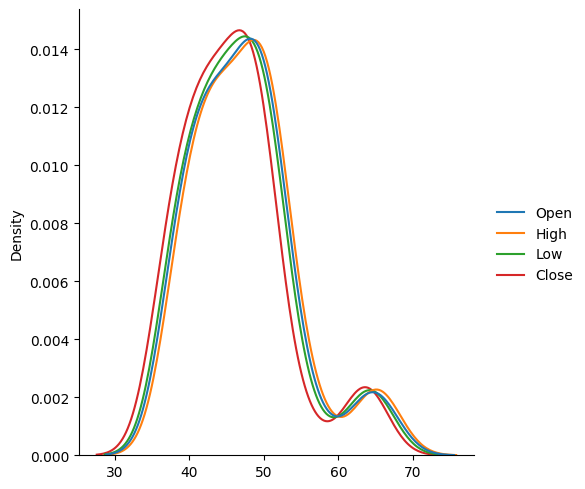

In [ ]:
# PLotting the distribution of open, close, high and low prices of stocks

# preparing the data for the plot

# Considering only on entry of prices per day
daily_stock_prices = data[['Date','Open','High','Low','Close','Volume']].drop_duplicates(keep ='first') # ensures only one record of prices per day
print(daily_stock_prices)

sns.displot(data=daily_stock_prices[['Open','High','Low','Close']], kind='kde', palette="tab10");

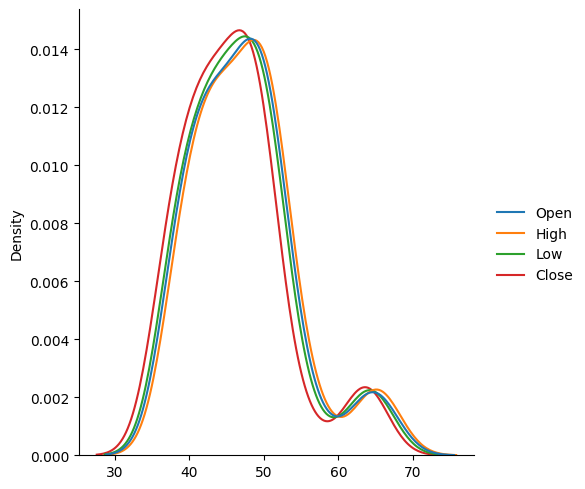

In [ ]:
# The above step combined into a single line without having to define a new DataFrame

sns.displot(data=data[['Date','Open','High','Low','Close']].drop_duplicates(keep ='first').reset_index().drop(['Date','index'], axis =1)[['Open','High','Low','Close']], kind='kde', palette="tab10");

#### Distribution of traded volume

<Axes: xlabel='Volume', ylabel='Count'>

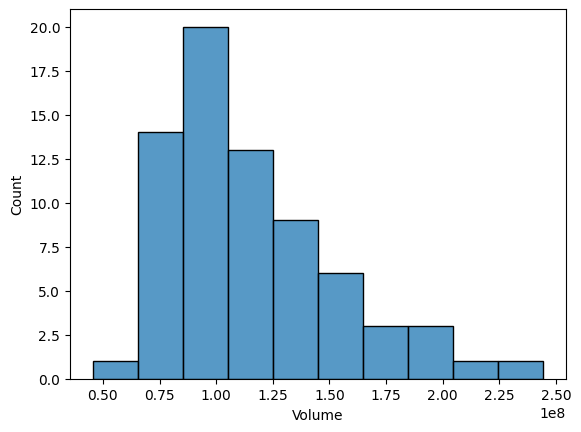

In [ ]:
# generating a histogram plot for the traded volume
sns.histplot(data=daily_stock_prices, x='Volume')

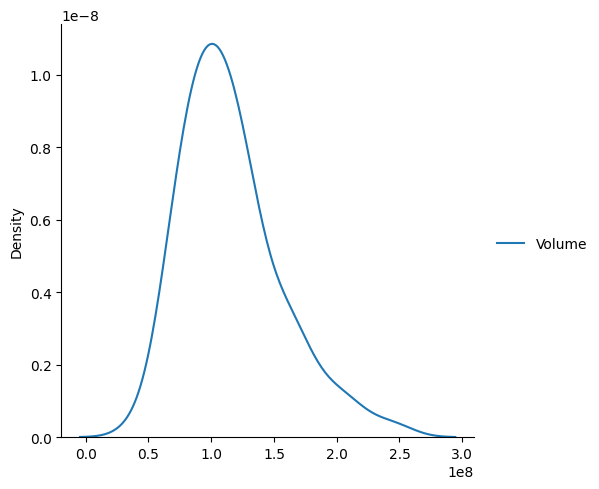

In [ ]:
# represent the above plot without having to create a new sub dataframe
sns.displot(data=data[['Date','Volume']].drop_duplicates(keep ='first').reset_index().drop(['Date','index'], axis =1)[['Volume']], kind='kde', palette="tab10");

#### Plotting the counts of different labels

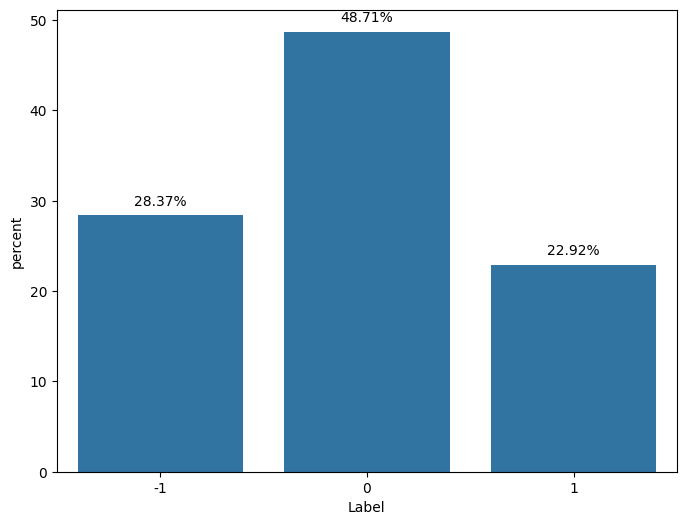

In [ ]:
# Plotting the percentage of negative (-1), neutral (0) and positive (1) stock news about the company
plt.figure(figsize=(8, 6))
plot = sns.countplot(data=data, x='Label',stat= "percent")
for p in plot.patches:
    plot.annotate(f'{p.get_height():.2f}%', (p.get_x() + p.get_width() /2, p.get_height()), ha='center', va='center', xytext=(0, 10), textcoords='offset points')
plt.show()

* The above distribution shows that the news have been neutral in almost 50 percent of the news content

####  Plotting the distribution of content length

In [ ]:
'''
Creating a new column 'News_length'to the data DAtaFrame with the
number of words in the corresponding news content
'''
data['News_Length'] = data['News'].apply(lambda x: len(x.split()))
data.head()

,Date,News,Open,High,Low,Close,Volume,Label,News_Length
0,2019-01-02,The tech sector experienced a significant dec...,41.740002,42.244999,41.482498,40.246914,130672400,-1,45
1,2019-01-02,Apple lowered its fiscal Q1 revenue guidance ...,41.740002,42.244999,41.482498,40.246914,130672400,-1,50
2,2019-01-02,Apple cut its fiscal first quarter revenue fo...,41.740002,42.244999,41.482498,40.246914,130672400,-1,48
3,2019-01-02,This news article reports that yields on long...,41.740002,42.244999,41.482498,40.246914,130672400,-1,50
4,2019-01-02,Apple's revenue warning led to a decline in U...,41.740002,42.244999,41.482498,40.246914,130672400,-1,49


<Axes: xlabel='News_Length', ylabel='Count'>

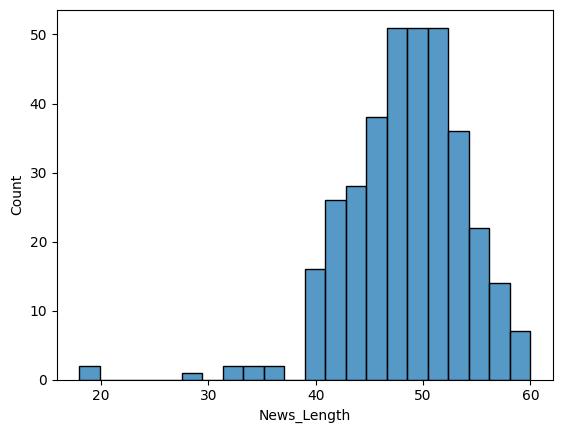

In [ ]:
# Plotting the distribution of length of the news content
sns.histplot(data=data, x='News_Length')

* Majority of the news content has been published in the range of 40 to 60 words with the average length being around 50 words

#### Computing the statistics of news length column

In [ ]:
# calculating the statistics of the news content
data['News_Length'].describe()

,News_Length
count,349.000000
mean,48.349570
std,5.717324
min,18.000000
25%,45.000000
50%,49.000000
75%,52.000000
max,60.000000


* The average length of the articles is around 48 words

### **Bivariate Analysis**

* Correlation
* Sentiment Polarity vs Price
* Date vs Price

**Note**: The above points are listed to provide guidance on how to approach bivariate analysis. Analysis has to be done beyond the above listed points to get maximum scores.

#### Correlation

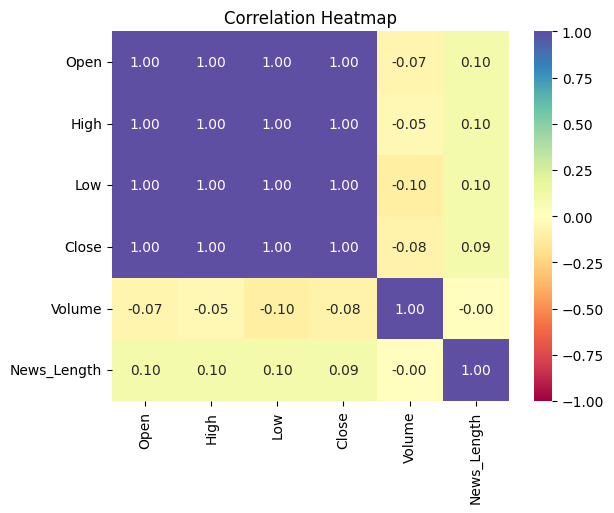

In [ ]:
# Creating a heatmap among all the numerical columns
cols = ['Open','High','Low','Close','Volume','News_Length']
sns.heatmap(
    data[cols].corr(), annot=True, vmin=-1, vmax=1, fmt=".2f", cmap="Spectral"
)
plt.title("Correlation Heatmap")
plt.show()

#### Sentiment Polarity vs. Price


<Axes: xlabel='Label', ylabel='Open'>

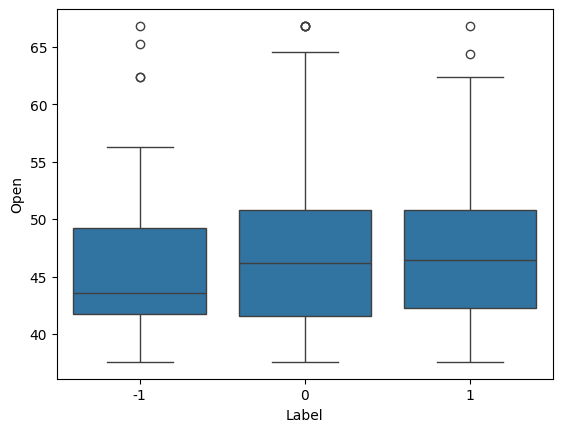

In [ ]:
# Sentiment polarity vs Open price

# From this graph the distribution of open prices under each label is seen


sns.boxplot(data=data, x="Label", y=data['Open'])

* The 50 percentile mark is considerably low when the polarity is negative

<Axes: xlabel='Label', ylabel='Close'>

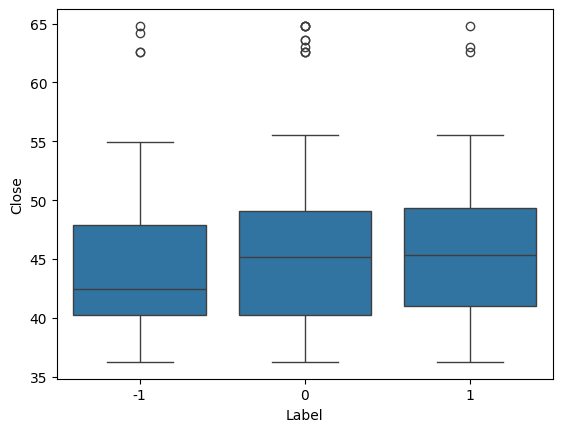

In [ ]:
sns.boxplot(data=data, x="Label", y=data['Close'])

* The 50 percentile mark is considerably low when the polarity is negative

<Axes: xlabel='Label', ylabel='High'>

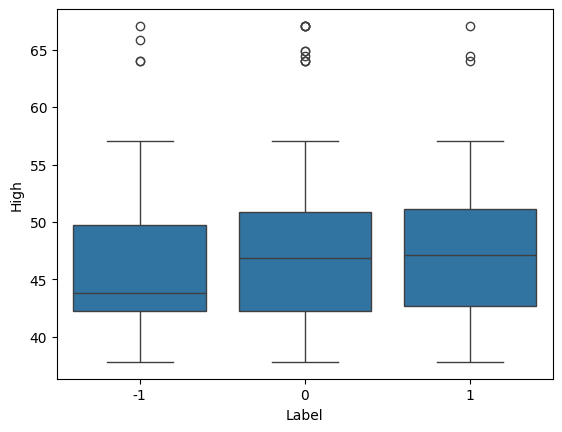

In [ ]:
sns.boxplot(data=data, x="Label", y=data['High'])

* The 50 percentile mark is considerably low when the polarity is negative

<Axes: xlabel='Label', ylabel='Low'>

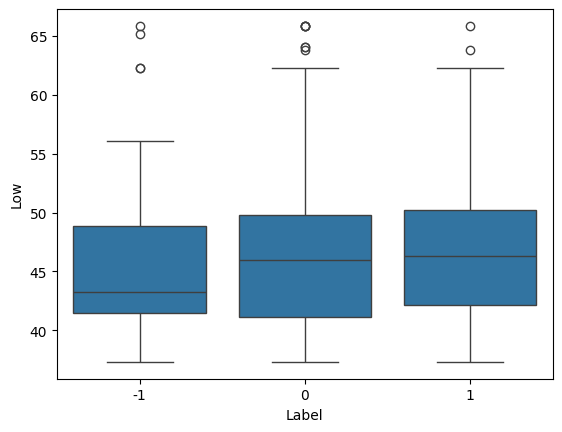

In [ ]:
sns.boxplot(data=data, x="Label", y=data['Low'])

* The 50 percentile mark is considerably low when the polarity is negative

#### Date vs. Price plots

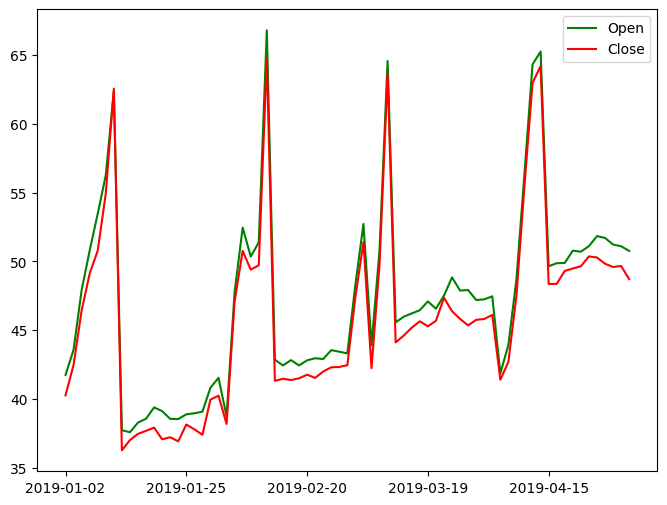

In [ ]:
# Plotting the daily Open and close prices of the Stocks

from matplotlib.ticker import MaxNLocator
plt.figure(figsize=(8, 6))
plt.plot(data['Date'],data['Open'],'-g')
plt.plot(data['Date'],data['Close'],'-r')

plt.legend(['Open', 'Close'])
plt.gca().xaxis.set_major_locator(MaxNLocator(nbins=6))
plt.show()

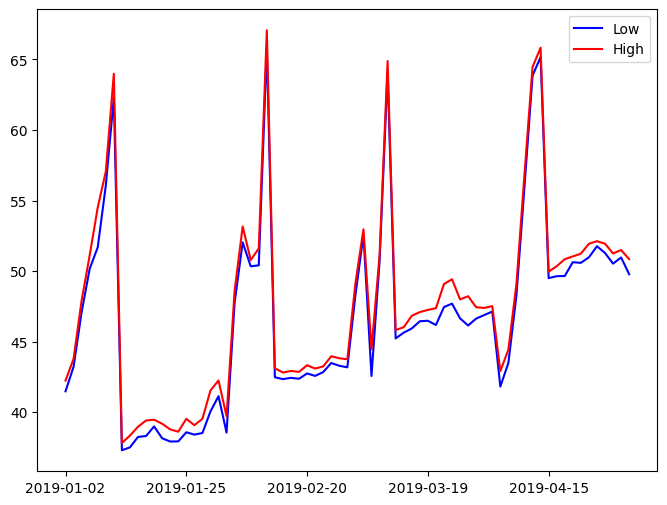

In [ ]:
# PLotting the daily High and Low values of the Stocks
plt.figure(figsize=(8, 6))
plt.plot(data['Date'],data['Low'],'-b')
plt.plot(data['Date'],data['High'],'-r')

plt.legend(['Low', 'High'])
plt.gca().xaxis.set_major_locator(MaxNLocator(nbins=6))
plt.show()

#### Date vs. Volume

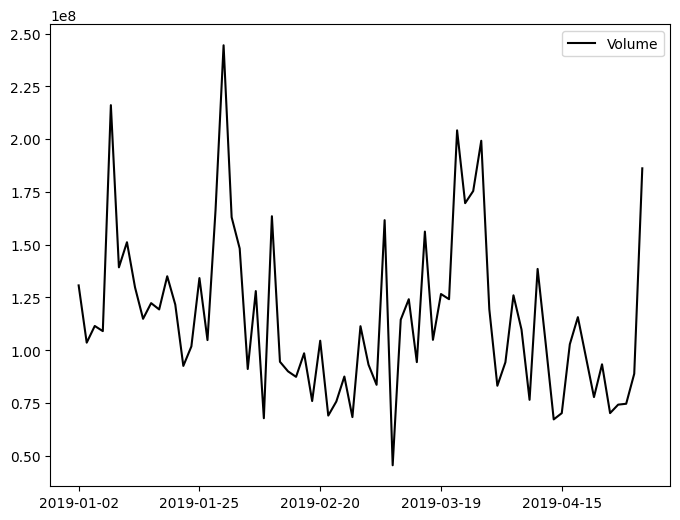

In [ ]:
# PLotting the daily traded volume of the Stocks
plt.figure(figsize=(8, 6))
plt.plot(data['Date'],data['Volume'],'-k')
plt.gca().xaxis.set_major_locator(MaxNLocator(nbins=6))
plt.legend(['Volume'])
plt.show()

#### Label vs. Volume

<Axes: xlabel='Label', ylabel='Volume'>

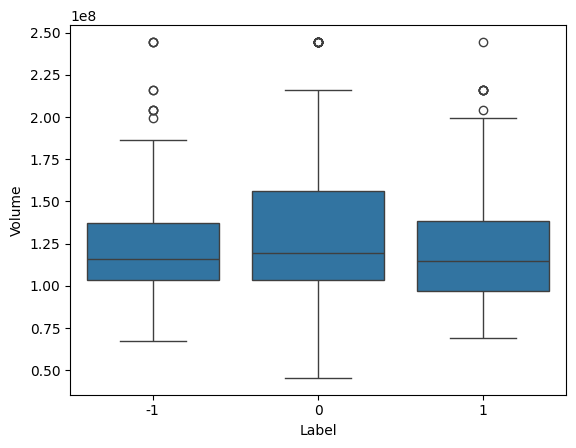

In [ ]:
sns.boxplot(data=data, x="Label", y=data['Volume'])

* The trade Volumes are higher when the polarity is non negative

## **Data Preprocessing**

###Converting Date column into datetime format

In [ ]:
# The Date column in the data dataframe must be converted to datetime format
data['Date'] =pd.to_datetime(data['Date'])
data.head()

,Date,News,Open,High,Low,Close,Volume,Label,News_Length
0,2019-01-02,The tech sector experienced a significant dec...,41.740002,42.244999,41.482498,40.246914,130672400,-1,45
1,2019-01-02,Apple lowered its fiscal Q1 revenue guidance ...,41.740002,42.244999,41.482498,40.246914,130672400,-1,50
2,2019-01-02,Apple cut its fiscal first quarter revenue fo...,41.740002,42.244999,41.482498,40.246914,130672400,-1,48
3,2019-01-02,This news article reports that yields on long...,41.740002,42.244999,41.482498,40.246914,130672400,-1,50
4,2019-01-02,Apple's revenue warning led to a decline in U...,41.740002,42.244999,41.482498,40.246914,130672400,-1,49


###Splitting the data

In [ ]:
# Taking out the independent variable
X = data['News']

# Taking out the target variable
y = data['Label']


In [ ]:
# Split data into training and testing set.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# resetting the index values permanently  for each subset of the data
X_train.reset_index(drop=True, inplace=True)
X_test.reset_index(drop=True, inplace=True)
y_train.reset_index(drop=True, inplace=True)
y_test.reset_index(drop=True, inplace=True)

In [ ]:
# Checking the shape of the news content subsets

print("Train data shape",X_train.shape)
print("Test data shape ",X_test.shape)



Train data shape (279,)
Test data shape  (70,)


In [ ]:
# Checking the shape of the labels subsets
print("Train label shape",y_train.shape)
print("Test label shape ",y_test.shape)

Train label shape (279,)
Test label shape  (70,)


In [ ]:
# Checking the top 5 rows of each subset
# THe indices are starting from 0 and increasing uniformly

print(X_train.head())
print(X_test.head())
print(y_train.head())
print(y_test.head())



0     The European Commission has initiated an inve...
1     Several Chinese retailers, including Alibaba-...
2     The Lynx Equity Strategies analysts, KC Rajku...
3     In Asia, gold prices rose to over six-month h...
4     Mercedes Benz sold over 2.31 million passenge...
Name: News, dtype: object
0     Google and Facebook disenabled their research...
1     In early trading, U.S. stock futures were fla...
2     Facebook, aiming to compete with Alexa, Siri,...
3     The European Union's Competition Commissioner...
4     Alibaba, the Chinese e-commerce giant and sec...
Name: News, dtype: object
0    0
1   -1
2   -1
3    1
4    1
Name: Label, dtype: int64
0    0
1    0
2   -1
3   -1
4    0
Name: Label, dtype: int64


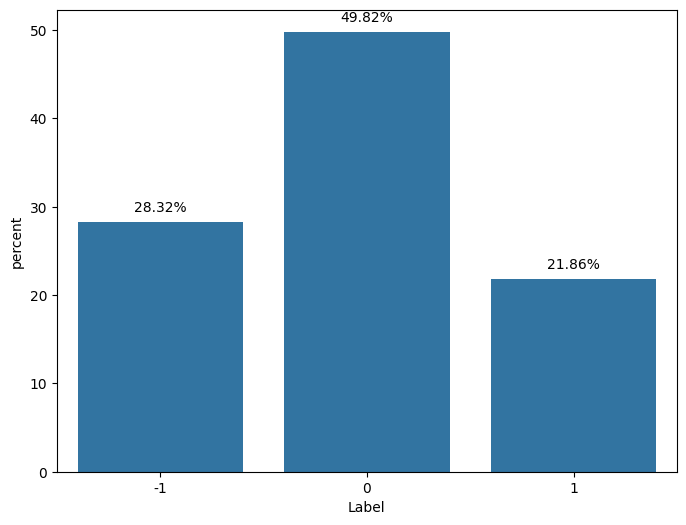

In [ ]:
# Checking the label distribution in the training subset

plt.figure(figsize=(8, 6))
plot = sns.countplot(x=y_train,stat= "percent")
for p in plot.patches:
    plot.annotate(f'{p.get_height():.2f}%', (p.get_x() + p.get_width() /2, p.get_height()), ha='center', va='center', xytext=(0, 10), textcoords='offset points')
plt.show()

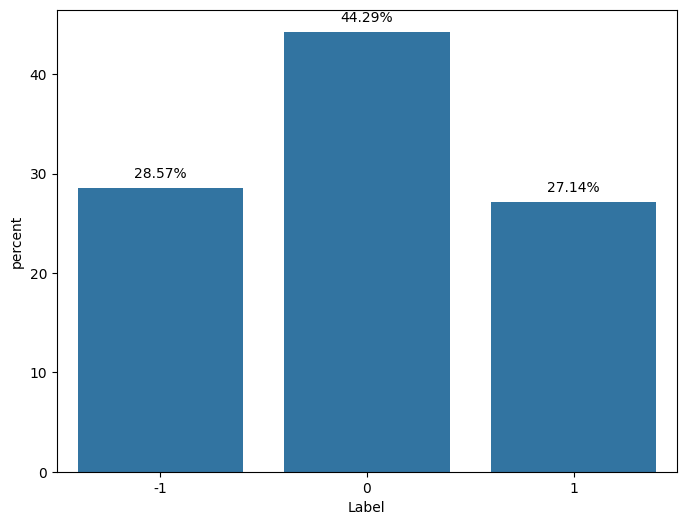

In [ ]:
# Checking the label distribution in the testing subset

plt.figure(figsize=(8, 6))
plot = sns.countplot(x=y_test,stat= "percent")
for p in plot.patches:
    plot.annotate(f'{p.get_height():.2f}%', (p.get_x() + p.get_width() /2, p.get_height()), ha='center', va='center', xytext=(0, 10), textcoords='offset points')
plt.show()

* The distribution of labels in the training and test samples is similar to that of the input population which is a good sign for the analysis

## **Word Embeddings**

#### **Word2Vec**

##### Defining the model

In [ ]:
# Generating the vocabulary from the data
# It is a list of lists


words_list = [item.split(" ") for item in data['News'].values]
print(words_list)


[['', 'The', 'tech', 'sector', 'experienced', 'a', 'significant', 'decline', 'in', 'the', 'aftermarket', 'following', "Apple's", 'Q1', 'revenue', 'warning.', 'Notable', 'suppliers,', 'including', 'Skyworks,', 'Broadcom,', 'Lumentum,', 'Qorvo,', 'and', 'TSMC,', 'saw', 'their', 'stocks', 'drop', 'in', 'response', 'to', "Apple's", 'downward', 'revision', 'of', 'its', 'revenue', 'expectations', 'for', 'the', 'quarter,', 'previously', 'announced', 'in', 'January.'], ['', 'Apple', 'lowered', 'its', 'fiscal', 'Q1', 'revenue', 'guidance', 'to', '$84', 'billion', 'from', 'earlier', 'estimates', 'of', '$89-$93', 'billion', 'due', 'to', 'weaker', 'than', 'expected', 'iPhone', 'sales.', 'The', 'announcement', 'caused', 'a', 'significant', 'drop', 'in', "Apple's", 'stock', 'price', 'and', 'negatively', 'impacted', 'related', 'suppliers,', 'leading', 'to', 'broader', 'market', 'declines', 'for', 'tech', 'indices', 'such', 'as', 'Nasdaq', '10'], ['', 'Apple', 'cut', 'its', 'fiscal', 'first', 'quarter

In [ ]:
# Creating a model of Word2Vec
# Each word is a vector of 300 features

vec_size = 300
model_W2V = Word2Vec(words_list, vector_size = vec_size, min_count = 1, window=5, workers = 6)

In [ ]:
# The length of the vocabulary list

print("Length of the vocabulary is", len(list(model_W2V.wv.key_to_index)))

Length of the vocabulary is 4682


##### Extracting information from the generated Word2Vec model

In [ ]:
'''
Creating a Dictionary with words (qualified based on min. count)
 of our vocabulary as keys and their
    corresponding vectors from the above model as values
'''
# Retrieving the words present in the Word2Vec model's vocabulary
words = list(model_W2V.wv.key_to_index.keys())

# Retrieving word vectors for all the words present in the model's vocabulary
wvs = model_W2V.wv[words].tolist()

# Creating a dictionary of words and their corresponding vectors
word_vector_dict = dict(zip(words, wvs))



##### Generating sentence embeddings using simple average of all the words appearing in the sentence

In [ ]:
'''
 Defining a function which takes all the words in the article which qualified
 into the model vocabulary and averages their vectors to get the sentence embedding
'''
# Using average function to calculate the vector for the document (each news article)

# The argument 'doc' is each text entry under the News column in the in the raw data

def average_vectorizer_Word2Vec(doc):
    # Initializing a feature vector for the sentence
    feature_vector = np.zeros((vec_size,), dtype="float64")

    # Creating a list of words in the sentence that are present in the model vocabulary
    words_in_vocab = [word for word in doc.split() if word in words]

    # adding the vector representations of the words occuring in the sentence
    for word in words_in_vocab:
        feature_vector += np.array(word_vector_dict[word])

    # Dividing by the number of words to get the average vector
    if len(words_in_vocab) != 0:
        feature_vector /= len(words_in_vocab)

    return feature_vector

In [ ]:
# creating a dataframe of the vectorized documents
# Each row is the embedding of a news article

# DataFrame for the training data

X_train_Word2Vec = pd.DataFrame(X_train.apply(average_vectorizer_Word2Vec).tolist(), columns=['Feature '+str(i) for i in range(vec_size)])
print(X_train_Word2Vec.head())

# DataFrame for the test data
X_test_Word2Vec = pd.DataFrame(X_test.apply(average_vectorizer_Word2Vec).tolist(), columns=['Feature '+str(i) for i in range(vec_size)])
print(X_test_Word2Vec.head())


# Printing the shape of the generated DataFrames
print("Shape of the train data",X_train_Word2Vec.shape)
print("Shape of the test data",X_test_Word2Vec.shape)

   Feature 0  Feature 1  Feature 2  Feature 3  Feature 4  Feature 5  \
0   0.000780   0.028875   0.001766   0.017902  -0.003784  -0.033407   
1   0.000815   0.032417   0.001741   0.019751  -0.004713  -0.037338   
2   0.000881   0.025595   0.000868   0.016063  -0.003429  -0.029628   
3   0.001388   0.038230   0.002002   0.023901  -0.005233  -0.044314   
4   0.000934   0.030699   0.001882   0.018517  -0.004161  -0.035324   

   Feature 6  Feature 7  Feature 8  Feature 9  ...  Feature 290  Feature 291  \
0   0.023763   0.058477   0.005249  -0.008176  ...     0.012494     0.031379   
1   0.026867   0.064618   0.005143  -0.009387  ...     0.014545     0.034237   
2   0.020941   0.051390   0.004879  -0.007085  ...     0.011150     0.027390   
3   0.031738   0.077358   0.007058  -0.011188  ...     0.016358     0.040859   
4   0.025372   0.060263   0.005134  -0.008687  ...     0.013183     0.032480   

   Feature 292  Feature 293  Feature 294  Feature 295  Feature 296  \
0     0.024867    -0.0

### **6.2 Sentence Transformer**

In [ ]:
# defining the model
model = SentenceTransformer('sentence-transformers/all-MiniLM-L6-v2')

In [ ]:
# encoding the dataset

X_train_embedding_matrix = model.encode(X_train, show_progress_bar=True)
X_test_embedding_matrix = model.encode(X_test, show_progress_bar=True)

Batches:   0%|          | 0/9 [00:00<?, ?it/s]

Batches:   0%|          | 0/3 [00:00<?, ?it/s]

In [ ]:
# printing the shape of the embedding matrix
print(X_train_embedding_matrix.shape)
print(X_test_embedding_matrix.shape)


(279, 384)
(70, 384)


## **Sentiment Analysis**

### **Model Evaluation Criterion**

**Note:**  
You can use the helper functions provided below to:
- Plot a **confusion matrix** (`plot_confusion_matrix`)
- Generate key **classification metrics** like accuracy, recall, precision, and F1-score (`model_performance_classification_sklearn`)

These are ready-to-use. However, you’re welcome to explore and write your own evaluation code if you prefer. Feel free to modify or extend these as per your learning goals!

##### **Utility Functions**

In [ ]:
def plot_confusion_matrix(actual, predicted):
    """
    Plot a confusion matrix to visualize the performance of a classification model.

    Parameters:
    actual (array-like): The true labels.
    predicted (array-like): The predicted labels from the model.

    Returns:
    None: Displays the confusion matrix plot.
    """

    # Compute the confusion matrix.
    cm = confusion_matrix(actual, predicted)

    # Create a new figure with a specified size
    plt.figure(figsize=(5, 4))

    # Define the labels for the confusion matrix dynamically from the data
    label_list = sorted(list(np.unique(np.concatenate((actual, predicted)))))

    # Plot the confusion matrix using a heatmap with annotations
    sns.heatmap(cm, annot=True, fmt='.0f', cmap='Blues', xticklabels=label_list, yticklabels=label_list)

    # Label for the y-axis
    plt.ylabel('Actual')

    # Label for the x-axis
    plt.xlabel('Predicted')

    # Title of the plot
    plt.title('Confusion Matrix')

    # Display the plot
    plt.show()

In [ ]:
def model_performance_classification_sklearn(actual, predicted):
    """
    Compute various performance metrics for a classification model using sklearn.

    Parameters:
    model (sklearn classifier): The classification model to evaluate.
    predictors (array-like): The independent variables used for predictions.
    target (array-like): The true labels for the dependent variable.

    Returns:
    pandas.DataFrame: A DataFrame containing the computed metrics (Accuracy, Recall, Precision, F1-score).
    """

    # Compute Accuracy
    acc = accuracy_score(actual,predicted)
    # Compute Recall
    recall = recall_score(actual,predicted,average='weighted')
    # Compute Precision
    precision = precision_score(actual,predicted,average='weighted')
    # Compute F1-score
    f1 = f1_score(actual,predicted,average='weighted')

    # Create a DataFrame to store the computed metrics
    df_perf = pd.DataFrame(
        {
            "Accuracy": [acc],
            "Recall": [recall],
            "Precision": [precision],
            "F1": [f1],
        }
    )
    # Return the DataFrame with the metrics
    return df_perf

### **Build Random Forest Models using different text embeddings**

#### ** Word2Vec text embeddings for Random Forest model**

##### Model 1 ( n_estimators = 100, max_depth = 3)

In [ ]:
# Building the model
# Model 1 ( n_estimators = 100, max_depth = 3)

rf_word2vec_100_3= RandomForestClassifier(n_estimators = 100, max_depth = 3, random_state = 42)

# Fitting the model
rf_word2vec_100_3.fit(X_train_Word2Vec, y_train)


RandomForestClassifier(max_depth=3, random_state=42)

In [ ]:
# Predicting on train data
y_pred_train = rf_word2vec_100_3.predict(X_train_Word2Vec)

# Predicting on test data
y_pred_test = rf_word2vec_100_3.predict(X_test_Word2Vec)

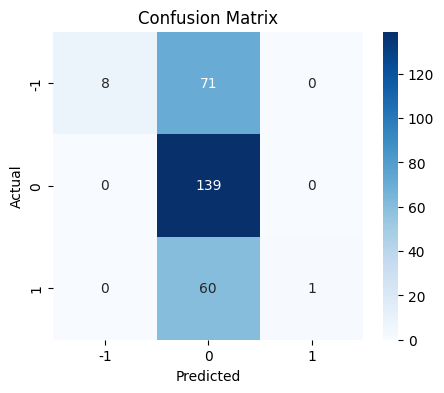

In [ ]:
# Plotting the confusion matrix on training data
plot_confusion_matrix(y_train, y_pred_train)

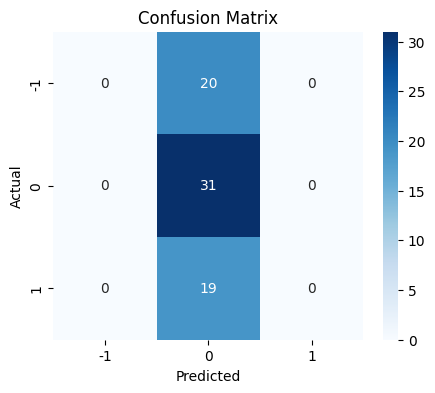

In [ ]:
# Plotting the confusion matrix on testing data
plot_confusion_matrix(y_test, y_pred_test)

In [ ]:
# Calculating the performance metrics of the model on both training and testing data

train_metrics_Word2Vec_RF = model_performance_classification_sklearn(y_train,y_pred_train)
print("The metrics on the training set is: \n",train_metrics_Word2Vec_RF)

test_metrics_Word2Vec_RF = model_performance_classification_sklearn(y_test,y_pred_test)
print("The metrics on the test set is: \n",test_metrics_Word2Vec_RF)

The metrics on the training set is: 
    Accuracy    Recall  Precision        F1
0  0.530466  0.530466   0.758277  0.397762
The metrics on the test set is: 
    Accuracy    Recall  Precision        F1
0  0.442857  0.442857   0.196122  0.271853


##### Model 2 ( n_estimators = 200, max_depth = 10)

In [ ]:
# Building the model
# Model 2 ( n_estimators = 100, max_depth = 10)

rf_word2vec_100_10= RandomForestClassifier(n_estimators = 100, max_depth = 10, random_state = 42)
rf_word2vec_100_10.fit(X_train_Word2Vec, y_train) # Fitting the model


RandomForestClassifier(max_depth=10, random_state=42)

In [ ]:
# Predicting on train data
y_pred_train = rf_word2vec_100_10.predict(X_train_Word2Vec)

# Predicting on test data
y_pred_test = rf_word2vec_100_10.predict(X_test_Word2Vec)



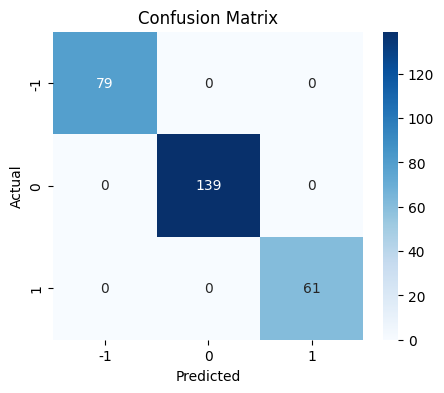

In [ ]:
# Plotting the confusion matrix on training data

plot_confusion_matrix(y_train, y_pred_train)


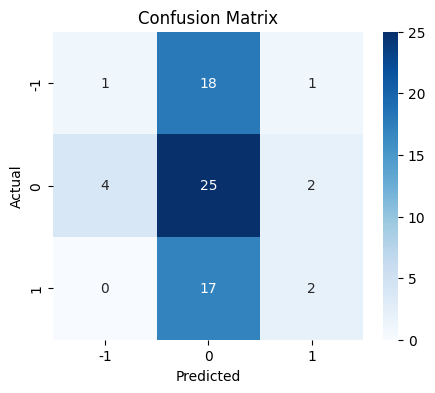

In [ ]:
# Plotting the confusion matrix on testing data

plot_confusion_matrix(y_test, y_pred_test)

In [ ]:
# Calculating the performance metrics of the model on bothe training and testing data

train_metrics_Word2Vec_RF = model_performance_classification_sklearn(y_train,y_pred_train)
print("The metrics on the training set is: \n",train_metrics_Word2Vec_RF)

test_metrics_Word2Vec_RF = model_performance_classification_sklearn(y_test,y_pred_test)
print("The metrics on the test set is: \n",test_metrics_Word2Vec_RF)

The metrics on the training set is: 
    Accuracy  Recall  Precision   F1
0       1.0     1.0        1.0  1.0
The metrics on the test set is: 
    Accuracy  Recall  Precision        F1
0       0.4     0.4   0.350238  0.311423


##### Model 3 ( n_estimators = 200, max_depth = 3)

In [ ]:
# Building the model
# Model 2 ( n_estimators = 200, max_depth = 3)

rf_word2vec_200_3= RandomForestClassifier(n_estimators = 200, max_depth = 3, random_state = 42)
rf_word2vec_200_3.fit(X_train_Word2Vec, y_train)

RandomForestClassifier(max_depth=3, n_estimators=200, random_state=42)

In [ ]:
# Predicting on train data
y_pred_train = rf_word2vec_200_3.predict(X_train_Word2Vec)

# Predicting on test data
y_pred_test = rf_word2vec_200_3.predict(X_test_Word2Vec)

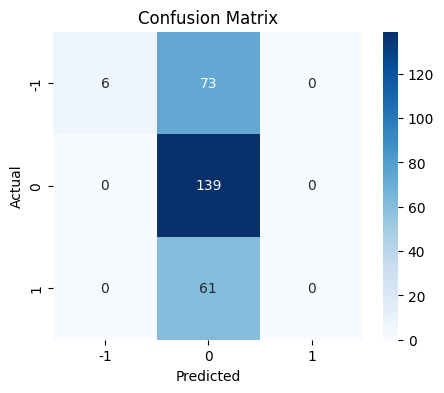

In [ ]:
# Plotting the confusion matrix on training data
plot_confusion_matrix(y_train, y_pred_train)


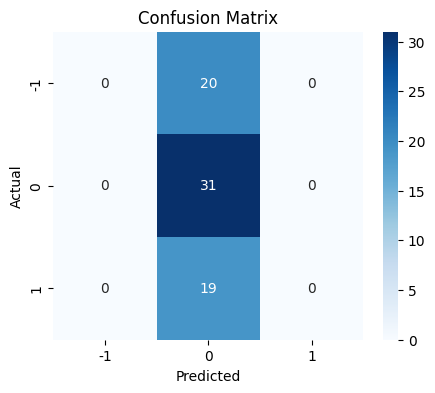

In [ ]:

# Plotting the confusion matrix on testing data
plot_confusion_matrix(y_test, y_pred_test)


In [ ]:
# Calculating the performance metrics of the model on bothe training and testing data
train_metrics_Word2Vec_RF = model_performance_classification_sklearn(y_train,y_pred_train)
print("The metrics on the training set is: \n",train_metrics_Word2Vec_RF)
test_metrics_Word2Vec_RF = model_performance_classification_sklearn(y_test,y_pred_test)
print("The metrics on the test set is: \n",test_metrics_Word2Vec_RF)

The metrics on the training set is: 
    Accuracy    Recall  Precision        F1
0  0.519713  0.519713    0.53682  0.376144
The metrics on the test set is: 
    Accuracy    Recall  Precision        F1
0  0.442857  0.442857   0.196122  0.271853


#### **Using embeddings from pre-trained Sentence transformer for Random forest model**


In [ ]:
# Building the model
rf_transformer = RandomForestClassifier(n_estimators = 100, max_depth = 3, random_state = 42)

# Fitting on train data
rf_transformer.fit(X_train_embedding_matrix, y_train)

RandomForestClassifier(max_depth=3, random_state=42)

In [ ]:
# Predicting on train data
y_pred_train = rf_transformer.predict(X_train_embedding_matrix)

# Predicting on test data
y_pred_test = rf_transformer.predict(X_test_embedding_matrix)

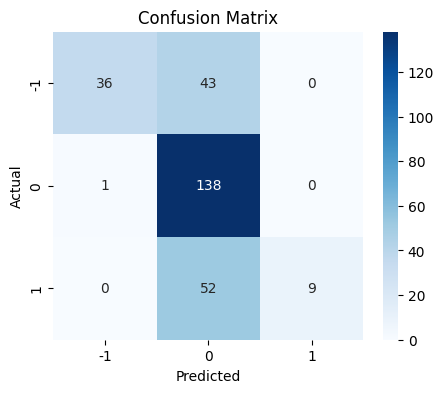

In [ ]:
# Plotting the confusion matrix on training data
plot_confusion_matrix(y_train, y_pred_train)


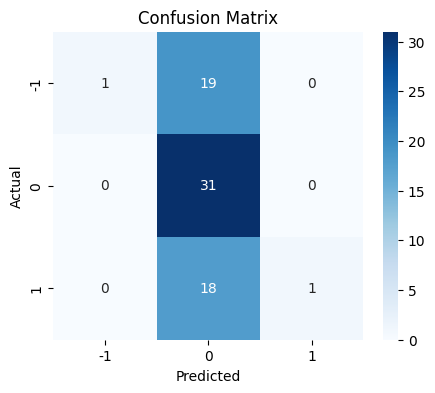

In [ ]:
# Plotting the confusion matrix on testing data
plot_confusion_matrix(y_test, y_pred_test)

In [ ]:
# Calculating the performance metrics of the model on bothe training and testing data

train_metrics_pretrained_RF = model_performance_classification_sklearn(y_train,y_pred_train)
print("The metrics on the training set is: \n",train_metrics_pretrained_RF)

test_metrics_pretrained_RF = model_performance_classification_sklearn(y_test,y_pred_test)
print("The metrics on the test set is: \n",test_metrics_pretrained_RF)

The metrics on the training set is: 
    Accuracy    Recall  Precision       F1
0  0.655914  0.655914   0.789215  0.60161
The metrics on the test set is: 
    Accuracy    Recall  Precision        F1
0  0.471429  0.471429   0.759034  0.331699


### **Building Neural Network Models using different text embeddings**

#### **Word2Vec text embeddings for NN Models**

In [ ]:
import gc

# Clear previous sessions
tf.keras.backend.clear_session()
gc.collect()

# Model definition
model = Sequential() # Defineing the architecture type

# Input layer
model.add(Dense(128, activation='relu', input_shape=(X_train_Word2Vec.shape[1],)))

# Defining dropout of 0.3 to avoid overfitting
model.add(Dropout(0.3))

# Hidden layer
model.add(Dense(64, activation='relu'))

# Output layer
model.add(Dense(3, activation='softmax'))  # 3 output classes

# Compile
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',  # Since labels are integers
    metrics=['accuracy']
)

# Summary
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │        38,528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 46,979 (183.51 KB)

 Trainable params: 46,979 (183.51 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Map labels to non-negative integers
label_mapping = {-1: 0, 0: 1, 1: 2}
# y_train_mapped = y_train.map(label_mapping)
# y_test_mapped = y_test.map(label_mapping)
y_train_mapped = [label_mapping[label] for label in y_train]
y_test_mapped = [label_mapping[label] for label in y_test]





In [ ]:
# checking if the mapping worked

zipped_list = list(zip(y_train,y_train_mapped))
print(zipped_list)


[(0, 1), (-1, 0), (-1, 0), (1, 2), (1, 2), (0, 1), (-1, 0), (0, 1), (1, 2), (1, 2), (1, 2), (-1, 0), (1, 2), (0, 1), (-1, 0), (0, 1), (-1, 0), (0, 1), (0, 1), (1, 2), (-1, 0), (0, 1), (0, 1), (-1, 0), (0, 1), (1, 2), (1, 2), (-1, 0), (-1, 0), (-1, 0), (1, 2), (0, 1), (1, 2), (0, 1), (0, 1), (0, 1), (1, 2), (0, 1), (-1, 0), (-1, 0), (0, 1), (0, 1), (-1, 0), (0, 1), (0, 1), (0, 1), (0, 1), (0, 1), (0, 1), (0, 1), (0, 1), (0, 1), (0, 1), (-1, 0), (0, 1), (-1, 0), (0, 1), (1, 2), (-1, 0), (0, 1), (0, 1), (0, 1), (0, 1), (0, 1), (0, 1), (0, 1), (0, 1), (0, 1), (0, 1), (-1, 0), (0, 1), (-1, 0), (1, 2), (1, 2), (-1, 0), (1, 2), (-1, 0), (-1, 0), (1, 2), (0, 1), (-1, 0), (0, 1), (0, 1), (1, 2), (-1, 0), (-1, 0), (1, 2), (0, 1), (0, 1), (1, 2), (1, 2), (-1, 0), (-1, 0), (0, 1), (0, 1), (1, 2), (-1, 0), (0, 1), (0, 1), (0, 1), (1, 2), (-1, 0), (0, 1), (1, 2), (-1, 0), (-1, 0), (-1, 0), (1, 2), (1, 2), (0, 1), (0, 1), (0, 1), (0, 1), (0, 1), (0, 1), (0, 1), (0, 1), (-1, 0), (1, 2), (1, 2), (-1, 0

In [ ]:
# Converting the series type into np array type
# model.fit() does not accept Series as arguments

X_train_Word2Vec_np = np.array(X_train_Word2Vec)
X_test_Word2Vec_np = np.array(X_test_Word2Vec)
y_train_mapped_np = np.array(y_train_mapped)
y_test_mapped_np = np.array(y_test_mapped)

In [ ]:
# Fitting the model


history = model.fit(
    # X_train_Word2Vec, y_train_mapped,
    # validation_data=(X_test_Word2Vec, y_test_mapped),
    X_train_Word2Vec_np, y_train_mapped_np,
    validation_data=(X_test_Word2Vec_np, y_test_mapped_np),
    epochs=20,
    batch_size=32
)

Epoch 1/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 5s 125ms/step - accuracy: 0.3690 - loss: 1.0931 - val_accuracy: 0.4429 - val_loss: 1.0858
Epoch 2/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.5269 - loss: 1.0595 - val_accuracy: 0.4429 - val_loss: 1.0805
Epoch 3/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.4835 - loss: 1.0496 - val_accuracy: 0.4429 - val_loss: 1.0853
Epoch 4/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.4757 - loss: 1.0622 - val_accuracy: 0.4429 - val_loss: 1.0897
Epoch 5/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.4610 - loss: 1.0587 - val_accuracy: 0.4429 - val_loss: 1.0944
Epoch 6/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.5123 - loss: 1.0336 - val_accuracy: 0.4429 - val_loss: 1.0963
Epoch 7/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.4575 - loss: 1.0676 - val_accuracy: 0.4429 - val_loss: 1.0857
Epoch 8/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.5364 - loss: 1.0196 - val_accuracy: 0.4429 - val_loss: 1.0858

In [ ]:
# Predict class probabilities on training data
y_train_pred_probs = model.predict(X_train_Word2Vec_np)

# Convert probabilities to class labels
y_train_preds = tf.argmax(y_train_pred_probs, axis=1).numpy()

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step


In [ ]:
# Predict class probabilities on test data
y_test_pred_probs = model.predict(X_test_Word2Vec_np)

# Convert probabilities to class labels
y_test_preds = tf.argmax(y_test_pred_probs, axis=1).numpy()

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step


In [ ]:
# Convert back to [-1, 0, 1] to match utility function expectations
label_mapping = {2: 1, 0: -1, 1: 0}
y_train_preds = np.array([label_mapping[index] for index in y_train_preds])
y_test_preds = np.array([label_mapping[index] for index in y_test_preds])

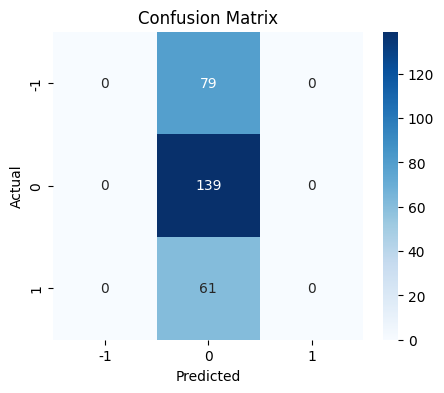

In [ ]:
# Plotting the confusion matrix on training data
plot_confusion_matrix(y_train, y_train_preds)

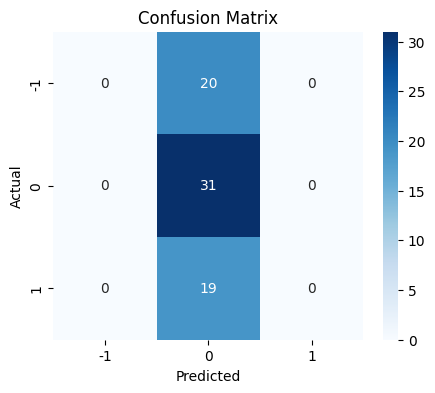

In [ ]:
# Plotting the confusion matrix on testing data
plot_confusion_matrix(y_test, y_test_preds)

In [ ]:
# Calculating the performance metrics of the model on bothe training and testing data

train_metrics_Word2Vec_NN = model_performance_classification_sklearn(y_train, y_train_preds)
print("The metrics on the training set is: \n",train_metrics_Word2Vec_NN)

test_metrics_Word2Vec_NN = model_performance_classification_sklearn(y_test, y_test_preds)
print("The metrics on the test set is: \n",test_metrics_Word2Vec_NN)

The metrics on the training set is: 
    Accuracy    Recall  Precision        F1
0  0.498208  0.498208   0.248211  0.331344
The metrics on the test set is: 
    Accuracy    Recall  Precision        F1
0  0.442857  0.442857   0.196122  0.271853


#### **Sentence Transformer embeddings for NN Models**


In [ ]:
import gc

# Clear previous sessions
tf.keras.backend.clear_session()
gc.collect()

# Model definition
model = Sequential()
model.add(Dense(128, activation='relu', input_shape=(X_train_embedding_matrix.shape[1],)))
model.add(Dropout(0.3))
model.add(Dense(64, activation='relu'))
model.add(Dense(3, activation='softmax'))  # 2 output classes

# Compile
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',  # Since labels are integers
    metrics=['accuracy']
)

# Summary
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │        49,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 57,731 (225.51 KB)

 Trainable params: 57,731 (225.51 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Map labels to non-negative integers
label_mapping = {-1: 0, 0: 1, 1: 2}
# y_train_mapped = y_train.map(label_mapping)
# y_test_mapped = y_test.map(label_mapping)
y_train_mapped_st = [label_mapping[label] for label in y_train]
y_test_mapped_st = [label_mapping[label] for label in y_test]

In [ ]:
# checking if the mapping worked

zipped_list = list(zip(y_train,y_train_mapped_st))
print(zipped_list)

[(0, 1), (-1, 0), (-1, 0), (1, 2), (1, 2), (0, 1), (-1, 0), (0, 1), (1, 2), (1, 2), (1, 2), (-1, 0), (1, 2), (0, 1), (-1, 0), (0, 1), (-1, 0), (0, 1), (0, 1), (1, 2), (-1, 0), (0, 1), (0, 1), (-1, 0), (0, 1), (1, 2), (1, 2), (-1, 0), (-1, 0), (-1, 0), (1, 2), (0, 1), (1, 2), (0, 1), (0, 1), (0, 1), (1, 2), (0, 1), (-1, 0), (-1, 0), (0, 1), (0, 1), (-1, 0), (0, 1), (0, 1), (0, 1), (0, 1), (0, 1), (0, 1), (0, 1), (0, 1), (0, 1), (0, 1), (-1, 0), (0, 1), (-1, 0), (0, 1), (1, 2), (-1, 0), (0, 1), (0, 1), (0, 1), (0, 1), (0, 1), (0, 1), (0, 1), (0, 1), (0, 1), (0, 1), (-1, 0), (0, 1), (-1, 0), (1, 2), (1, 2), (-1, 0), (1, 2), (-1, 0), (-1, 0), (1, 2), (0, 1), (-1, 0), (0, 1), (0, 1), (1, 2), (-1, 0), (-1, 0), (1, 2), (0, 1), (0, 1), (1, 2), (1, 2), (-1, 0), (-1, 0), (0, 1), (0, 1), (1, 2), (-1, 0), (0, 1), (0, 1), (0, 1), (1, 2), (-1, 0), (0, 1), (1, 2), (-1, 0), (-1, 0), (-1, 0), (1, 2), (1, 2), (0, 1), (0, 1), (0, 1), (0, 1), (0, 1), (0, 1), (0, 1), (0, 1), (-1, 0), (1, 2), (1, 2), (-1, 0

In [ ]:
# Converting the series type into np array type
# model.fit() does not accept Series as arguments

X_train_embedding_matrix_np = np.array(X_train_embedding_matrix)
X_test_embedding_matrix_np = np.array(X_test_embedding_matrix)
y_train_mapped_np_st= np.array(y_train_mapped)
y_test_mapped_np_st = np.array(y_test_mapped)

In [ ]:
# Fitting the model
history = model.fit(
    X_train_embedding_matrix_np, y_train_mapped_np_st,
    validation_data=(X_test_embedding_matrix_np, y_test_mapped_np_st),
    epochs=20,
    batch_size=32
    )

Epoch 1/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 5s 67ms/step - accuracy: 0.5321 - loss: 1.0659 - val_accuracy: 0.4429 - val_loss: 1.0633
Epoch 2/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - accuracy: 0.5145 - loss: 1.0145 - val_accuracy: 0.4429 - val_loss: 1.0521
Epoch 3/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - accuracy: 0.4977 - loss: 0.9865 - val_accuracy: 0.4429 - val_loss: 1.0398
Epoch 4/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.5223 - loss: 0.9385 - val_accuracy: 0.4429 - val_loss: 1.0243
Epoch 5/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - accuracy: 0.5256 - loss: 0.9185 - val_accuracy: 0.5286 - val_loss: 0.9960
Epoch 6/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - accuracy: 0.5752 - loss: 0.8671 - val_accuracy: 0.5143 - val_loss: 0.9806
Epoch 7/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 45ms/step - accuracy: 0.6142 - loss: 0.7936 - val_accuracy: 0.5286 - val_loss: 0.9722
Epoch 8/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.6333 - loss: 0.7836 - val_accuracy: 0.5429 - val_loss: 0.9323


In [ ]:
# Predict class probabilities on training data
y_train_pred_probs = model.predict(X_train_embedding_matrix_np)

# Convert probabilities to class labels
y_train_preds = tf.argmax(y_train_pred_probs, axis=1).numpy()

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step


In [ ]:
# Predict class probabilities on test data
y_test_pred_probs = model.predict(X_test_embedding_matrix_np)

# Convert probabilities to class labels
y_test_preds = tf.argmax(y_test_pred_probs, axis=1).numpy()

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step


In [ ]:
# Convert back to [-1, 0, 1] to match utility function expectations
label_mapping = {2: 1, 0: -1, 1: 0}
y_train_preds = np.array([label_mapping[index] for index in y_train_preds])
y_test_preds = np.array([label_mapping[index] for index in y_test_preds])

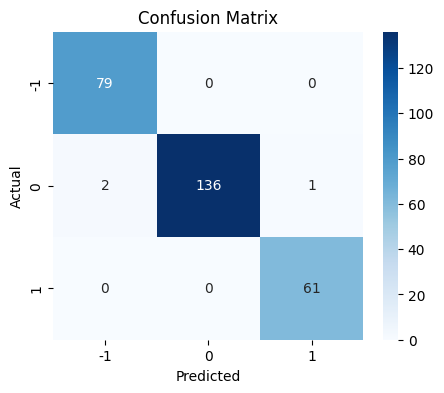

In [ ]:
# Plotting the confusion matrix on training data
plot_confusion_matrix(y_train, y_train_preds)

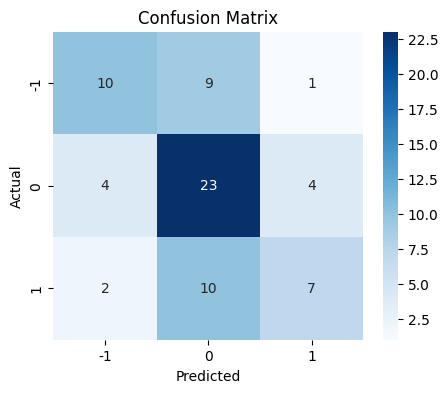

In [ ]:
# Plotting the confusion matrix on testing data

plot_confusion_matrix(y_test, y_test_preds)

In [ ]:
# Calculating the performance metrics of the model on bothe training and testing data
train_metrics_pretrained_NN = model_performance_classification_sklearn(y_train, y_train_preds)
print("The metrics on the training set is: \n",train_metrics_pretrained_NN)

test_metrics_pretrained_NN = model_performance_classification_sklearn(y_test, y_test_preds)
print("The metrics on the test set is: \n",test_metrics_pretrained_NN)

The metrics on the training set is: 
    Accuracy    Recall  Precision        F1
0  0.989247  0.989247   0.989482  0.989248
The metrics on the test set is: 
    Accuracy    Recall  Precision        F1
0  0.571429  0.571429   0.579422  0.560371


### **Model Performance Summary and Final Model Selection**

In [ ]:
# Concatenate the training performance metrics from different models into a single DataFrame
models_comparison_training_data = pd.concat(
    [
        train_metrics_Word2Vec_RF.T,  # Random Forest using Word2Vec embeddings
        train_metrics_pretrained_RF.T,  # Neural Network using Word2Vec embeddings
        train_metrics_Word2Vec_NN.T,  # Random Forest using Sentence Transformer embeddings
        train_metrics_pretrained_NN.T   # Neural Network using Sentence Transformer embeddings
    ],
    axis=1  # Concatenate along columns (i.e., each model's metrics form one column)
)

# Assigning meaningful column names for each model for clarity in the output DataFrame
models_comparison_training_data.columns = [
    "Word2Vec (Random Forest) Model 3",
    "Word2Vec (Neural Network)",
    "Sentence Transformer (Random Forest)",
    "Sentence Transformer (Neural Network)"
]

# Print the training performance comparison table
print("Training performance comparison:")
models_comparison_training_data

Training performance comparison:


,Word2Vec (Random Forest) Model 3,Word2Vec (Neural Network),Sentence Transformer (Random Forest),Sentence Transformer (Neural Network)
Accuracy,0.519713,0.655914,0.498208,0.989247
Recall,0.519713,0.655914,0.498208,0.989247
Precision,0.536820,0.789215,0.248211,0.989482
F1,0.376144,0.601610,0.331344,0.989248


In [ ]:
# Concatenate the training performance metrics from different models into a single DataFrame
models_comparison_test_data = pd.concat(
    [
        test_metrics_Word2Vec_RF.T,  # Random Forest using Word2Vec embeddings
        test_metrics_pretrained_RF.T,  # Neural Network using Word2Vec embeddings
        test_metrics_Word2Vec_NN.T,  # Random Forest using Sentence Transformer embeddings
        test_metrics_pretrained_NN.T   # Neural Network using Sentence Transformer embeddings
    ],
    axis=1  # Concatenate along columns (i.e., each model's metrics form one column)
)

# Assigning meaningful column names for each model for clarity in the output DataFrame
models_comparison_test_data.columns = [
    "Word2Vec (Random Forest) Model 3",
    "Word2Vec (Neural Network)",
    "Sentence Transformer (Random Forest)",
    "Sentence Transformer (Neural Network)"
]

# Print the training performance comparison table
print("Testing data performance comparison:")
models_comparison_test_data

Testing data performance comparison:


,Word2Vec (Random Forest) Model 3,Word2Vec (Neural Network),Sentence Transformer (Random Forest),Sentence Transformer (Neural Network)
Accuracy,0.442857,0.471429,0.442857,0.571429
Recall,0.442857,0.471429,0.442857,0.571429
Precision,0.196122,0.759034,0.196122,0.579422
F1,0.271853,0.331699,0.271853,0.560371


## **Conclusions and Recommendations**

The input data consists of news articles published which are relevant to the company's stock prices

The data provided consists of multiple articles per day for a period of 71 days

The Open and Close prices of each day along with the corresponding High and Low values have been recorded

The Close prices are lower than the Low price 98 percent of the days

The news articles have been neutral for 50 percent of the data

THe stock prices have gradually increased over the observed period of time

A total of 349 records have been provided for the models to be built with average size of each article being around 48 words

The data might be considered ideally enough for generating an ideal AI solution

In this project, the following models were generated

	* Random forest model with Word2Vec
	* Random forest model with pretrained MiniLM-L6-v2
	* Neural Network model with Word2Vec
	* Neural Network model with pretrained MiniLM-L6-v2

**The Neural Network model with pretrained Sentence transformer has shown best results on test data**

**The best accuracy of this model on test data is around 50 percent but the model seems to have over fitted on the training data as its accuracy on training data is around 99 percent.**

**The Neural Network model with Word2Vec has shown considerably reliable results on both training and testing data with the numbers being close on both sets**